# PROJECT 2: IMAGE RECOGNITION

# 1. Dataset Analysis

## Step 1: Imports & Setup

In [1]:
import os

# Data Manipulation and Visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# PyTorch Core and Neural Network Modules
import torch
import torch.nn as nn
import torch.optim as optim

# PyTorch Vision (For handling image data)
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split

import wandb

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Step 2: Load Dataset & Analyze Class Distribution


Analyzing the distribution of classes in the dataset:


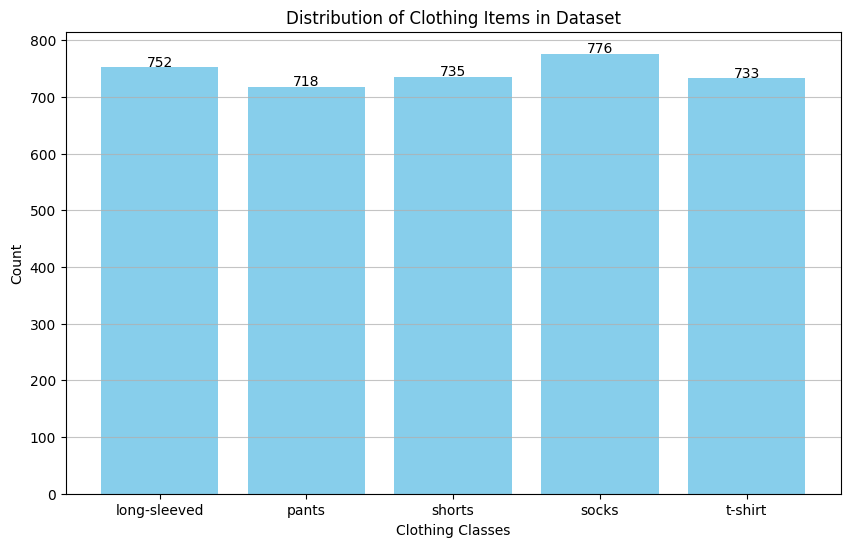

In [2]:
# Define the path to your data folder
data_dir = "./EiDL_CNN_SoSe_26"

# Apply a basic transform just to load the images as PyTorch tensors
basic_transform = transforms.Compose([
    transforms.ToTensor()
])

# Load the dataset using ImageFolder (this maps folder names to class names automatically)
full_dataset = datasets.ImageFolder(root=data_dir, transform=basic_transform)

def analyze_clothing_distribution(dataset):
    # Get the string names of our classes (e.g., 'long-sleeved', 'pants', etc.)
    class_names = dataset.classes
    
    # Grab all the numerical labels instantly without needing a DataLoader loop
    all_labels = dataset.targets
    
    # Count occurrences of each class
    unique, counts = np.unique(all_labels, return_counts=True)
    
    # Plot distribution
    plt.figure(figsize=(10, 6))
    plt.bar(class_names, counts, color='skyblue')
    plt.xlabel('Clothing Classes')
    plt.ylabel('Count')
    plt.title('Distribution of Clothing Items in Dataset')
    plt.grid(axis='y', alpha=0.75)
    
    # Add count labels on top of each bar
    for i, count in enumerate(counts):
        # I changed the vertical offset to +2 so it scales better for smaller datasets
        plt.text(i, count + 2, str(count), ha='center') 
        
    plt.show()

print("\nAnalyzing the distribution of classes in the dataset:")
analyze_clothing_distribution(full_dataset)

## Step 3: Visualize Sample Images


Visualizing sample images from each class:


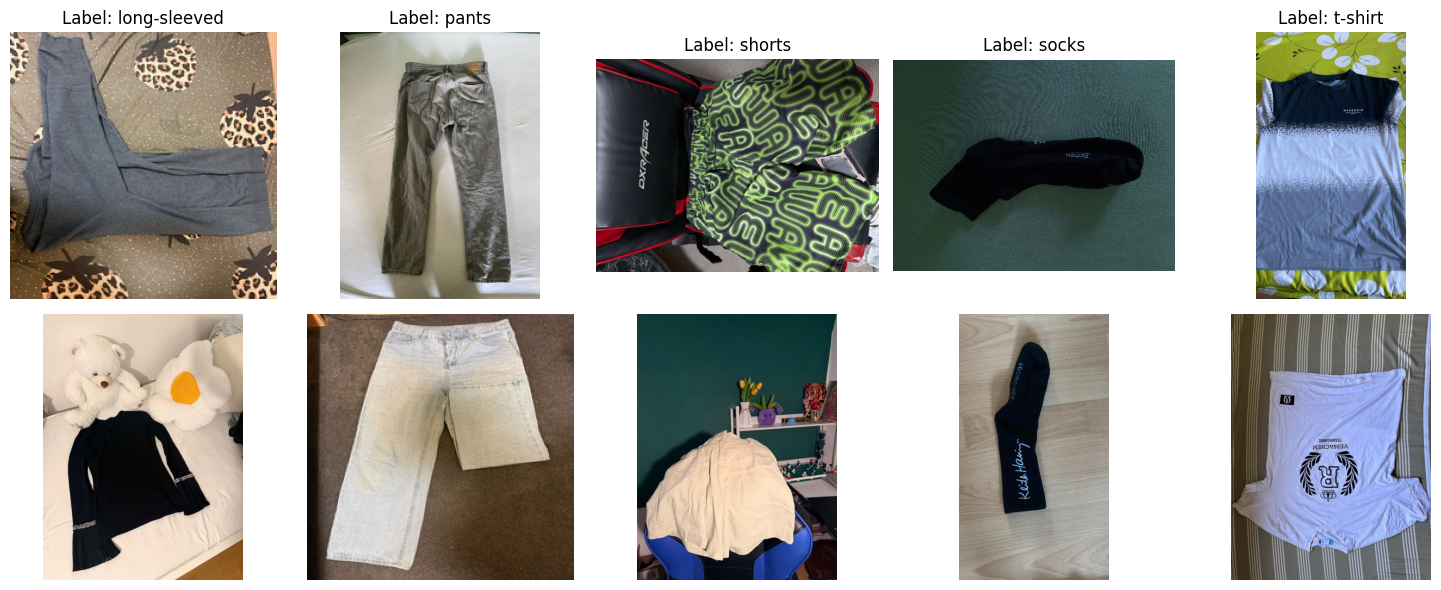

In [3]:
def show_clothing_images(dataset, samples_per_class=2):
    num_classes = len(dataset.classes)
    
    # Create a 2D grid of images (rows = samples_per_class, cols = num_classes)
    # Dynamically adjust the height of the figure based on how many rows are wanted
    fig, axes = plt.subplots(samples_per_class, num_classes, figsize=(15, 3 * samples_per_class))
    
    # Dictionary to track how many images have plotted for each class
    class_counts = {i: 0 for i in range(num_classes)}
    
    dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
    
    for images, labels in dataloader:
        label_idx = labels[0].item()
        
        # Check if we still need more samples for this specific class
        if class_counts[label_idx] < samples_per_class:
            class_name = dataset.classes[label_idx]
            
            # Prepare the image for Matplotlib
            img = images[0].permute(1, 2, 0).cpu().numpy()
            
            # Determine exactly where this image goes in the grid
            row = class_counts[label_idx]
            col = label_idx
            
            # Select the specific subplot axis
            ax = axes[row, col]
            
            ax.imshow(img)
            ax.axis('off')
            
            # Only put the title on the very top row to keep it clean
            if row == 0:
                ax.set_title(f"Label: {class_name}")
            
            # Increment our counter for this specific class
            class_counts[label_idx] += 1
            
        # Stop looping once EVERY class has hit the target number of samples
        if all(count == samples_per_class for count in class_counts.values()):
            break

    plt.tight_layout()
    plt.show()

print(f"\nVisualizing sample images from each class:")
show_clothing_images(full_dataset, samples_per_class=2)

## Step 4: Analyze Image Properties


Analyzing image dimensions, aspect ratios, and color channels:


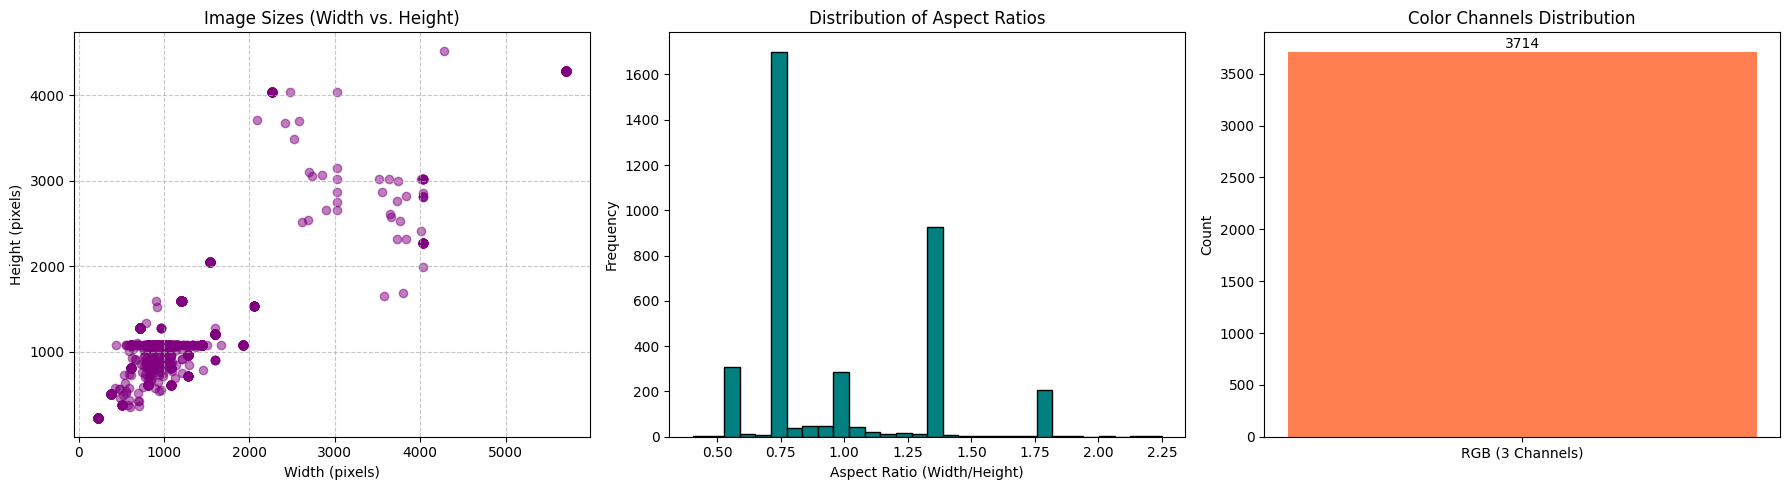

In [4]:
def analyze_image_properties(dataset):
    widths = []
    heights = []
    aspect_ratios = []
    channels = []
    
    # Using dataset.samples to get the raw file paths so we can inspect 
    # the original images before any PyTorch transforms are applied.
    for filepath, _ in dataset.samples:
        # Open the image using PIL (Python Imaging Library)
        with Image.open(filepath) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)
            
            # Record the color channels based on the image mode
            if img.mode == 'RGB':
                channels.append('RGB (3 Channels)')
            elif img.mode == 'RGBA':
                channels.append('RGBA (4 Channels)')
            elif img.mode == 'L':
                channels.append('Grayscale (1 Channel)')
            else:
                channels.append(f'Other ({img.mode})')

    #  Plotting the Results 
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Image Sizes (Width vs Height)
    axes[0].scatter(widths, heights, alpha=0.5, color='purple')
    axes[0].set_title('Image Sizes (Width vs. Height)')
    axes[0].set_xlabel('Width (pixels)')
    axes[0].set_ylabel('Height (pixels)')
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # 2. Aspect Ratios (Width / Height)
    axes[1].hist(aspect_ratios, bins=30, color='teal', edgecolor='black')
    axes[1].set_title('Distribution of Aspect Ratios')
    axes[1].set_xlabel('Aspect Ratio (Width/Height)')
    axes[1].set_ylabel('Frequency')
    
    # 3. Color Channels
    unique_channels, counts = np.unique(channels, return_counts=True)
    axes[2].bar(unique_channels, counts, color='coral')
    axes[2].set_title('Color Channels Distribution')
    axes[2].set_ylabel('Count')
    
    # Add count labels on top of the bar chart
    for i, count in enumerate(counts):
        axes[2].text(i, count + (max(counts)*0.01), str(count), ha='center')

    plt.tight_layout()
    plt.show()

print("\nAnalyzing image dimensions, aspect ratios, and color channels:")
analyze_image_properties(full_dataset)

### Dataset Challenges and Observations

Based on our exploratory data analysis, we have identified the following characteristics and potential challenges within our custom dataset:

* **Color Channels (Uniformity):** Fortunately, 100% of our images are standard RGB (3-channel). We do not have to worry about converting grayscale or stripping alpha (RGBA) channels.
* **Resolution Constraint Violations:** The dataset contains numerous images that violate the specified collection constraints (min 224x224, max 1920x1080 pixels). As visualized in the scatter plot, a massive portion of the dataset consists of high-resolution images reaching up to 3000x4000 pixels.
* **Inconsistent Aspect Ratios:** While the dominant aspect ratio is 0.75, there are outliers. 

**Impact on Preprocessing:** Because Convolutional Neural Networks require a strictly uniform input size, these varying dimensions and aspect ratios pose a challenge. If we blindly squash a 4000x3000 image into a square 224x224 tensor, the clothing items will become heavily distorted. We will need to address this using careful resizing and cropping transformations in the data loading pipeline.

## Step 5: Split the Dataset (80% / 10% / 10%)

In [5]:
# STRATIFIED SPLIT
# Get all targets so we can stratify based on them
targets = full_dataset.targets
indices = np.arange(len(targets))

# First split: 80% Train, 20% Temporary (Validation + Test)
train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, stratify=targets, random_state=42
)

# Second split: Divide the 20% Temporary into 10% Validation and 10% Test
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=temp_targets, random_state=42
)

print(f"Stratified Splits -> Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Stratified Splits -> Train: 2971, Val: 371, Test: 372


# 2. Data Preprocessing

## Step 1: Calculation of Metrics

In [6]:
# CALCULATE MEAN AND STD
# Resize images since they are in different sizes.
calc_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Create a temporary loader just for the training data to calculate stats
calc_dataset = datasets.ImageFolder(root=data_dir, transform=calc_transform)
calc_trainset = torch.utils.data.Subset(calc_dataset, train_idx)
# The tensor has shape [Batch_Size, Channels, Height, Width]
calc_loader = DataLoader(calc_trainset, batch_size=32, shuffle=False)

print("\nCalculating specific mean and std of the training set...")
mean = torch.zeros(3)
std = torch.zeros(3)
total_images = 0

# Split the calculation into batches to avoid memory issues
for images, _ in calc_loader:
    batch_samples = images.size(0)
    # Reshape to [Batch_Size, Channels, Height*Width].
    # images.size(1) is always 3 for RGB.
    # -1 means "flatten everything else that is left into a single line." It multiplies Height x Width.
    images = images.view(batch_samples, images.size(1), -1)
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_images += batch_samples

mean /= total_images
std /= total_images
print(f"Dataset Mean: {mean.tolist()}")
print(f"Dataset Std:  {std.tolist()}")


Calculating specific mean and std of the training set...
Dataset Mean: [0.5068483352661133, 0.476482629776001, 0.4548782706260681]
Dataset Std:  [0.2130146473646164, 0.20451568067073822, 0.19911669194698334]


## Step 2: Normalization & Augmentation & Dataloaders

In [7]:
# APPLY TRANSFORMS AND CREATE DATALOADERS
# Train transform includes the required augmentations
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),        # Resize slightly larger first
    transforms.RandomCrop(224),           # Random crop to target size
    transforms.RandomHorizontalFlip(),    # Augmentation: Flipping
    transforms.RandomRotation(15),        # Augmentation: Rotation
    transforms.ColorJitter(brightness=0.5, contrast=0.5), # Augmentation: Color
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())       # Normalization
])

# Validation/Test transform should NEVER have random augmentations!
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),        # Standard resize
    transforms.ToTensor(),
    transforms.Normalize(mean.tolist(), std.tolist())       # Normalization
])

# Load the data multiple times with the specific transforms
trainset_full = datasets.ImageFolder(root=data_dir, transform=train_transform)
valset_full   = datasets.ImageFolder(root=data_dir, transform=test_transform)
testset_full  = datasets.ImageFolder(root=data_dir, transform=test_transform)

# Apply our stratified indices
trainset = torch.utils.data.Subset(trainset_full, train_idx)
valset   = torch.utils.data.Subset(valset_full, val_idx)
testset  = torch.utils.data.Subset(testset_full, test_idx)

# Create the dataloaders
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
valloader   = DataLoader(valset, batch_size=32, shuffle=False)
testloader  = DataLoader(testset, batch_size=32, shuffle=False)

print("\nDataLoaders successfully created!")


DataLoaders successfully created!


## Step 3: Visualize Augmented Images


Visualizing augmented training images:


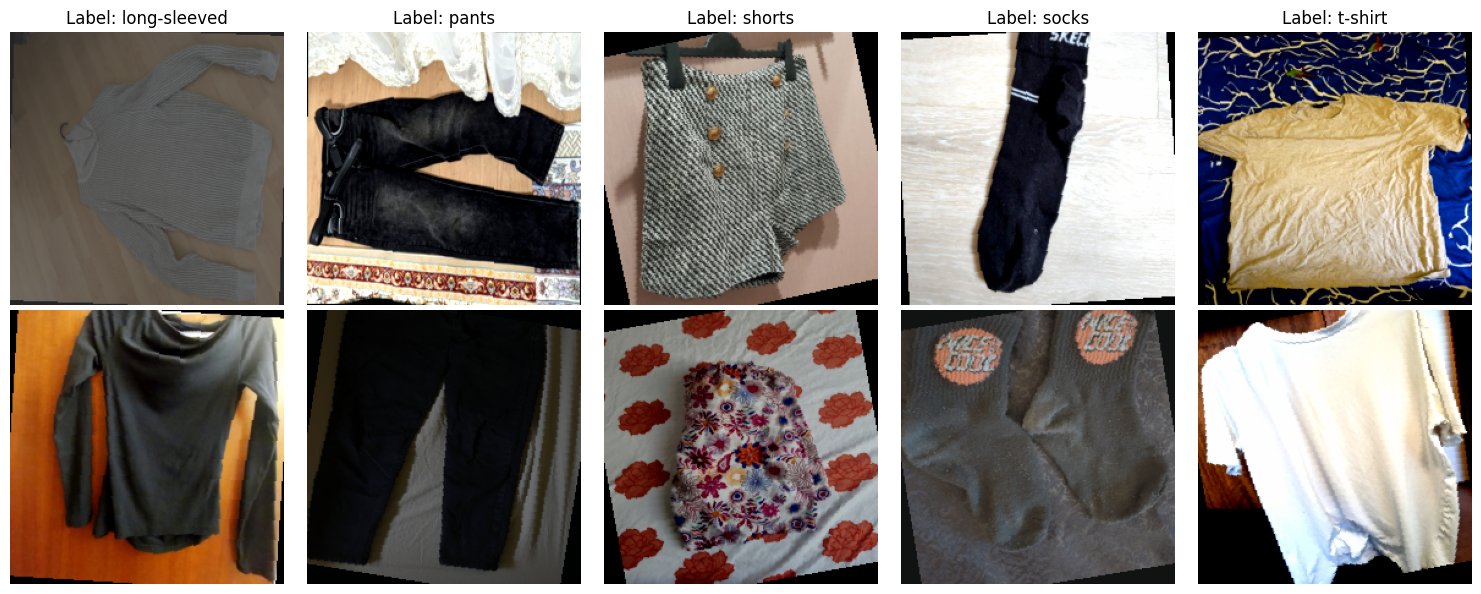

In [8]:
def show_clothing_augmented_images(dataset, samples_per_class=2):
    num_classes = len(dataset.dataset.classes) # .dataset is needed because we used Subset
    
    fig, axes = plt.subplots(samples_per_class, num_classes, figsize=(15, 3 * samples_per_class))
    class_counts = {i: 0 for i in range(num_classes)}
    
    dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
    
    # Grab the mean and std we calculated earlier and convert to numpy arrays
    # so we can use them to un-normalize the images
    mean_np = np.array(mean.tolist())
    std_np = np.array(std.tolist())
    
    for images, labels in dataloader:
        label_idx = labels[0].item()
        
        if class_counts[label_idx] < samples_per_class:
            class_name = dataset.dataset.classes[label_idx]
            
            # 1. Permute dimensions for Matplotlib
            img = images[0].permute(1, 2, 0).cpu().numpy()
            
            # 2. UN-NORMALIZE so Matplotlib can read the colors properly!
            img = (img * std_np) + mean_np
            
            # 3. Clip values to strictly stay between 0 and 1 (removes math artifacts)
            img = np.clip(img, 0, 1)
            
            row = class_counts[label_idx]
            col = label_idx
            ax = axes[row, col]
            
            ax.imshow(img)
            ax.axis('off')
            
            if row == 0:
                ax.set_title(f"Label: {class_name}")
            
            class_counts[label_idx] += 1
            
        if all(count == samples_per_class for count in class_counts.values()):
            break

    plt.tight_layout()
    plt.show()

print("\nVisualizing augmented training images:")
show_clothing_augmented_images(trainset, samples_per_class=2)

# 3. CNN Implementation

## Step 1: Implementing CNN Architecture

In [24]:
class ClothingCNN(nn.Module):
    def __init__(self):
        super(ClothingCNN, self).__init__()
        
        # CONVOLUTIONAL BLOCKS
        # in_channels is the number of channels in the input image (3 for RGB)
        # Block 1: Input (3, 224, 224) -> Output (16, 112, 112)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 2: Input (16, 112, 112) -> Output (32, 56, 56)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 3: Input (32, 56, 56) -> Output (64, 28, 28)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 4: Input (64, 28, 28) -> Output (128, 14, 14)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 5: Input (128, 14, 14) -> Output (128, 7, 7)
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.relu5 = nn.ReLU()
        self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # FLATTENING
        # We shrunk the image 5 times by a factor of 2: 224 -> 112 -> 56 -> 28 -> 14 -> 7
        # We have 128 channels. So the flattened size is: 128 * 7 * 7 = 6272
        
        # Fully Connected Layers (The Classifier)
        self.flatten = nn.Flatten()
        
        # Dropout helps prevent overfitting by randomly turning off 50% of neurons during training
        self.dropout = nn.Dropout(p=0.5) 
        
        # Set out_feature to 88 to get as close as posible to 800.000 parameters limit.
        self.fc1 = nn.Linear(in_features=6272, out_features=88)
        self.relu_fc = nn.ReLU()
        
        # Output layer: 5 classes (T-Shirts, Pants, Socks, Shorts, Long-sleeved)
        self.fc2 = nn.Linear(in_features=88, out_features=5)

    def forward(self, x):
        # Pass through convolutional blocks
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.pool4(self.relu4(self.conv4(x)))
        x = self.pool5(self.relu5(self.conv5(x)))
        
        # Flatten and pass through classifier
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.relu_fc(self.fc1(x))
        x = self.fc2(x)
        
        return x

# Instantiate the model and move it to your GPU
model = ClothingCNN().to(device)
print(model)

ClothingCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu4): ReLU()
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu5): ReLU()
  (pool5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.5, inplac

## Step 2: Proving the Parameter Count

In [25]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params:,}")
        
count_parameters(model)

Total trainable parameters: 797,493


## Step 3: Architectural Justifications

**1. Filter Sizes (3x3 Convolutions):**
Following the design philosophy of VGGNet (as discussed in Lecture 6), we exclusively used 3x3 convolution kernels. A 3x3 kernel is the smallest symmetric grid capable of capturing local spatial context (left/right, up/down). By stacking multiple 3x3 layers rather than using larger 5x5 or 7x7 filters, the network achieves the same effective receptive field while drastically reducing the total number of trainable parameters and introducing more non-linearities (ReLUs).

**2. Number of Layers and Spatial Reduction (5 Blocks):**
Because our input images are relatively large (224x224 RGB), flattening the image too early would result in a massive Fully Connected layer, instantly violating the < 800,000 parameter constraint. We implemented 5 convolutional blocks, each concluding with a 2x2 Max Pooling layer. This systematically halves the spatial dimensions 5 times ($224 \rightarrow 112 \rightarrow 56 \rightarrow 28 \rightarrow 14 \rightarrow 7$), allowing the network to extract deep hierarchical features (from simple edges to complex clothing parts) while squashing the spatial resolution to a highly manageable 7x7 grid before the classifier.

**3. Fully Connected Bottleneck:**
After flattening the final feature maps, the tensor contains 6,272 features. To strictly adhere to the assignment's parameter limit, the first Fully Connected layer acts as a deliberate bottleneck, condensing these features into a small dense vector (e.g., 64 or 88 neurons). This balances the model's capacity to learn complex decision boundaries while keeping the overall parameter count safely below the 800k threshold.

**4. Regularization (Dropout):**
A Dropout layer ($p=0.5$) is placed before the fully connected layers. Because our crowdsourced dataset likely contains noisy images and varying backgrounds, the model is at a high risk of overfitting to the training set. A 50% dropout rate forces the network to learn redundant representations of the clothing items, significantly improving its ability to generalize to the unseen validation and test sets.

# 4. Model Training

## Step 1: Defining Parameters and Functions

In [26]:
import time

# Define Hyperparameters
# These are the settings that control how the network learns.
# Tweak these later to try and get a better score
LEARNING_RATE = 0.001
EPOCHS = 15

# For SGD, momentum helps the optimizer maintain direction and can speed up convergence.
MOMENTUM = 0.9

# Loss and Optimizer 
# CrossEntropyLoss is the standard for Multi-Class classification
criterion = nn.CrossEntropyLoss()

# Adam is our optimizer. Giving it all the parameters to manage.
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Weights & Biases Configuration 
ENTITY = "eidl-thm"
PROJECT = "Übungsgruppe_Turhan_Muhammed_Pak_Reyyan"

# Generate a timestamp
timestamp = time.strftime("%Y%m%d_%H%M%S")
run_name = f"CNN_Adam_lr{LEARNING_RATE}_{timestamp}"

# We pack our settings into a config dictionary. 
# WandB uses this to generate beautiful comparative charts on their website.
wandb_config = {
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "batch_size": 32, # This matches the DataLoaders
    "architecture": "Custom CNN",
    "dataset": "Crowdsourced Clothing"
}

print(f"Initialization complete.")
print(f"Ready to launch run: {run_name} to project {PROJECT}")

Initialization complete.
Ready to launch run: CNN_Adam_lr0.001_20260622_205934 to project Übungsgruppe_Turhan_Muhammed_Pak_Reyyan


## Step 2: Training CNN

In [27]:
import copy

# Early Stopping Setup
best_val_loss = float('inf')  # Start with an infinitely high loss
patience = 3                  # How many epochs to wait for improvement before giving up
patience_counter = 0
best_model_weights = copy.deepcopy(model.state_dict()) # Backup of the best weights

print("Starting training process...")

# Start the W&B run using the variables we defined in the previous step
with wandb.init(
    entity=ENTITY,
    project=PROJECT,
    name=run_name,
    config=wandb_config) as run:
    
    for epoch in range(EPOCHS):
        
        # ==========================
        #       TRAINING PHASE
        # ==========================
        model.train() # This Turns On Dropout and allows weights to be updated
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for images, labels in trainloader:
            # 0. Push data to the GPU
            images, labels = images.to(device), labels.to(device)
            
            # 1. Zero the gradients
            optimizer.zero_grad()
            
            # 2. Forward Pass: The model takes a guess
            outputs = model(images)
            
            # 3. Calculate Loss: How wrong was the guess?
            loss = criterion(outputs, labels)
            
            # 4. Backward Pass: Calculate the gradients
            loss.backward()
            
            # 5. Optimizer Step: Adjust the weights based on the gradients
            optimizer.step()
            
            # Track Training Metrics
            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
        avg_train_loss = train_loss / total_train
        train_accuracy = correct_train / total_train
        
        
        # ==========================
        #      VALIDATION PHASE
        # ==========================
        model.eval() # Turns OFF Dropout
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        # Disable gradient calculations to save memory and speed up validation
        with torch.no_grad():
            for images, labels in valloader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                
        avg_val_loss = val_loss / total_val
        val_accuracy = correct_val / total_val
        
        
        # ==========================
        #   LOGGING & EARLY STOPPING
        # ==========================
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}")
        
        # Early Stopping Check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            # We found a new best model! Save a copy of the brain.
            best_model_weights = copy.deepcopy(model.state_dict())
            print("   -> Validation loss improved! Saving model parameters...")
        else:
            patience_counter += 1
            print(f"   -> No improvement. Patience: {patience_counter}/{patience}")
            
        # Send our metrics to Weights & Biases!
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": avg_val_loss,
            "val_accuracy": val_accuracy,
            "best_val_loss": best_val_loss,
            "patience_counter": patience_counter 
        })
        
        if patience_counter >= patience:
            print("Early stopping triggered! The model stopped learning to prevent overfitting.")
            break # Break out of the epoch loop entirely
        
    # Save the auto-generated ID into a global variable so the next cell can find it!
    saved_run_id = run.id
    print(f"W&B Run ID automatically saved: {saved_run_id}")

# FINAL CLEANUP
# Load the very best weights back into the model
model.load_state_dict(best_model_weights)

# Save the physical file to your hard drive (include this in your ZIP submission!)
torch.save(model.state_dict(), "best_clothing_cnn.pth")
print("\nTraining complete. Best model weights permanently saved as 'best_clothing_cnn.pth'.")

Starting training process...


Epoch [1/15] | Train Loss: 1.6102 | Train Acc: 0.2023 | Val Loss: 1.5877 | Val Acc: 0.2561
   -> Validation loss improved! Saving model parameters...
Epoch [2/15] | Train Loss: 1.5412 | Train Acc: 0.3066 | Val Loss: 1.4108 | Val Acc: 0.4259
   -> Validation loss improved! Saving model parameters...
Epoch [3/15] | Train Loss: 1.3997 | Train Acc: 0.4073 | Val Loss: 1.3511 | Val Acc: 0.4394
   -> Validation loss improved! Saving model parameters...
Epoch [4/15] | Train Loss: 1.3503 | Train Acc: 0.4302 | Val Loss: 1.3254 | Val Acc: 0.4690
   -> Validation loss improved! Saving model parameters...
Epoch [5/15] | Train Loss: 1.2653 | Train Acc: 0.4840 | Val Loss: 1.2489 | Val Acc: 0.4609
   -> Validation loss improved! Saving model parameters...
Epoch [6/15] | Train Loss: 1.2499 | Train Acc: 0.4857 | Val Loss: 1.2585 | Val Acc: 0.5094
   -> No improvement. Patience: 1/3
Epoch [7/15] | Train Loss: 1.1807 | Train Acc: 0.5231 | Val Loss: 1.2351 | Val Acc: 0.4987
   -> Validation loss improved! 

best_val_loss,█▆▅▅▄▄▄▃▃▃▃▂▂▂▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
patience_counter,▁▁▁▁▁█▁▁▁▁█▁▁▁▁
train_accuracy,▁▃▅▅▆▆▇▇▇▇▇████
train_loss,█▇▆▅▄▄▃▃▂▂▂▂▂▁▁
val_accuracy,▁▅▅▆▆▇▆▆▇▇▇▇█▇█
val_loss,█▆▅▅▄▄▄▃▃▃▃▂▂▂▁
best_val_loss,1.01693
epoch,15
patience_counter,0
train_accuracy,0.6099



Training complete. Best model weights permanently saved as 'best_clothing_cnn.pth'.


# 5. Model Evaluation

In [28]:
# Load the Best Model
model.load_state_dict(torch.load("best_clothing_cnn.pth"))
model.eval() 

all_preds = []
all_labels = []
test_loss = 0.0
total_test = 0

# Lists to hold the images we want to send to the W&B Media tab
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

print("Evaluating model on the Test Set and compiling W&B Dashboard...")

# We use resume="must" to tell W&B to append to the old run instead of making a new one
with wandb.init(entity=ENTITY, project=PROJECT, id=saved_run_id, resume="must") as run:

    # Run the Test Set
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item() * images.size(0)
            total_test += labels.size(0)
            
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Catch Misclassified Images for the W&B Dashboard
            for i in range(len(labels)):
                if predicted[i] != labels[i] and len(misclassified_images) < 15: # Cap at 15 to save upload bandwidth
                    
                    # We must un-normalize the image so it doesn't look like static on W&B!
                    img = images[i].cpu().permute(1, 2, 0).numpy()
                    mean_np = np.array(mean.tolist())
                    std_np = np.array(std.tolist())
                    img = (img * std_np) + mean_np
                    img = np.clip(img, 0, 1)
                    
                    misclassified_images.append(img)
                    misclassified_labels.append(labels[i].item())
                    misclassified_preds.append(predicted[i].item())

    # Calculate All Metrics
    avg_test_loss = test_loss / total_test
    test_accuracy = accuracy_score(all_labels, all_preds)

    # Raw metrics for each individual class (for the Table)
    p_class, r_class, f1_class, support_class = precision_recall_fscore_support(
        all_labels, all_preds, average=None
    )

    # The 6 Averaged Metrics (for the Bar Charts)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')

    # Build the W&B Artifacts
    class_names = testset.dataset.classes
    # The Class Metrics Table
    metrics_table = wandb.Table(columns=["Class", "Precision", "Recall", "F1-Score", "Support"])
    for i, class_name in enumerate(class_names):
        metrics_table.add_data(class_name, p_class[i], r_class[i], f1_class[i], support_class[i])

    # The Confusion Matrix Heatmap
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax)
    plt.title('Confusion Matrix: Clothing Classification', pad=20)
    plt.ylabel('Actual True Label')
    plt.xlabel('Model Predicted Label')
    plt.tight_layout()

    # The Misclassified Images Media Array
    wandb_misclassified = []
    for img, true_label, pred_label in zip(misclassified_images, misclassified_labels, misclassified_preds):
        caption = f"Truth: {class_names[true_label]} | Guessed: {class_names[pred_label]}"
        wandb_misclassified.append(wandb.Image(img, caption=caption))

    # Log Everything to Weights & Biases
    wandb.log({
        "test_loss": avg_test_loss,
        "test_acc": test_accuracy,
        "test/precision_macro": p_macro,
        "test/recall_macro": r_macro,
        "test/f1_macro": f1_macro,
        "test/precision_weighted": p_weight,
        "test/recall_weighted": r_weight,
        "test/f1_weighted": f1_weight,
        "Tables/Class_Metrics": metrics_table,
        "Media/Confusion_Matrix": wandb.Image(fig),
        "Media/Misclassified_Examples": wandb_misclassified
    })

    plt.close(fig) # Clean up computer memory

    print(f"\nEvaluation complete! Overall Test Accuracy: {test_accuracy * 100:.2f}%")

Evaluating model on the Test Set and compiling W&B Dashboard...


C:\Users\mami4\AppData\Local\Temp\ipykernel_12000\4106195651.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_clothing_cnn.pth"))



Evaluation complete! Overall Test Accuracy: 67.47%


test/f1_macro,▁
test/f1_weighted,▁
test/precision_macro,▁
test/precision_weighted,▁
test/recall_macro,▁
test/recall_weighted,▁
test_acc,▁
test_loss,▁
best_val_loss,1.01693
epoch,15
patience_counter,0
